In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [96]:
clientes    = pd.read_csv("dataset/data_cliente.csv")
ventas      = pd.read_csv("dataset/data_transaccional.csv")

In [97]:
clientes.head()

,customer_id,territory_id,segment,age_alicorp,has_credit_line,has_perfect_customer,has_marketing_impulse,target
0,1,T1,S3,9.0,1,0,1,1
1,2,T2,S3,0.0,0,1,1,0
2,3,T1,S3,4.0,1,0,0,0
3,4,T1,S3,2.0,0,1,0,0
4,5,T1,S3,2.0,0,1,1,0


In [98]:
clientes.shape

(5254, 8)

In [99]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 5254 entries, 0 to 5253
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            5254 non-null   int64  
 1   territory_id           5254 non-null   str    
 2   segment                5254 non-null   str    
 3   age_alicorp            5179 non-null   float64
 4   has_credit_line        5254 non-null   int64  
 5   has_perfect_customer   5254 non-null   int64  
 6   has_marketing_impulse  5254 non-null   int64  
 7   target                 5254 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 349.0 KB


In [100]:
clientes.describe(include="all")

,customer_id,territory_id,segment,age_alicorp,has_credit_line,has_perfect_customer,has_marketing_impulse,target
count,5254.000000,5254,5254,5179.000000,5254.000000,5254.000000,5254.000000,5254.000000
unique,NaN,6,6,NaN,NaN,NaN,NaN,NaN
top,NaN,T1,S3,NaN,NaN,NaN,NaN,NaN
freq,NaN,2630,4239,NaN,NaN,NaN,NaN,NaN
mean,2627.500000,NaN,NaN,5.044410,0.503807,0.332889,0.338980,0.162733
std,1516.843488,NaN,NaN,3.145493,0.500033,0.471292,0.473408,0.369157
min,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1314.250000,NaN,NaN,2.000000,0.000000,0.000000,0.000000,0.000000
50%,2627.500000,NaN,NaN,5.000000,1.000000,0.000000,0.000000,0.000000
75%,3940.750000,NaN,NaN,8.000000,1.000000,1.000000,1.000000,0.000000


In [101]:
clientes.isnull().sum().sort_values(ascending=False)

age_alicorp              75
customer_id               0
territory_id              0
segment                   0
has_credit_line           0
has_perfect_customer      0
has_marketing_impulse     0
target                    0
dtype: int64

In [102]:
ventas.isnull().sum().sort_values(ascending=False)

date                0
customer_id         0
product_id          0
category_product    0
amount              0
discount            0
dtype: int64

In [103]:
clientes.duplicated().sum()

np.int64(0)

In [104]:
ventas.duplicated().sum()

np.int64(6)

In [105]:
clientes.customer_id.nunique()

5254

In [106]:
ventas.category_product.nunique()

10

In [107]:
clientes["target"].value_counts()

target
0    4399
1     855
Name: count, dtype: int64

In [108]:
clientes["target"].value_counts(normalize=True)

target
0    0.837267
1    0.162733
Name: proportion, dtype: float64

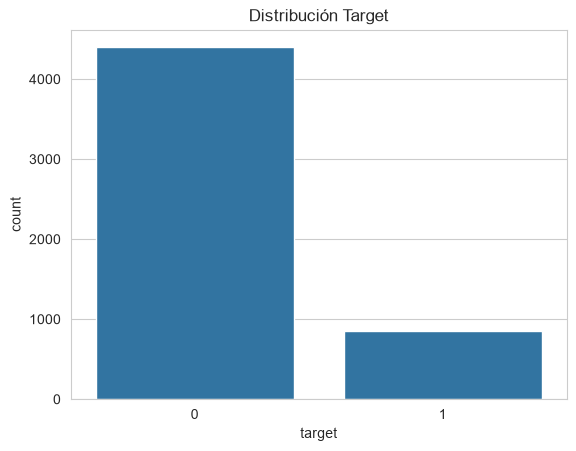

In [109]:
sns.countplot(
    data=clientes,
    x="target"
)

plt.title("Distribución Target")
plt.show()

In [110]:
clientes["age_alicorp"].describe()

count    5179.000000
mean        5.044410
std         3.145493
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: age_alicorp, dtype: float64

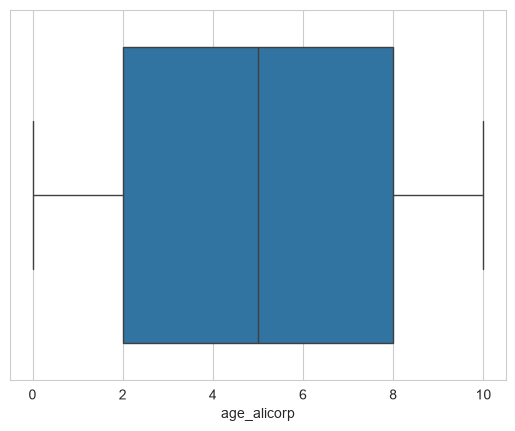

In [111]:
sns.boxplot(
    x=clientes["age_alicorp"]
)

plt.show()

In [112]:
clientes["has_credit_line"].value_counts(normalize=True)

has_credit_line
1    0.503807
0    0.496193
Name: proportion, dtype: float64

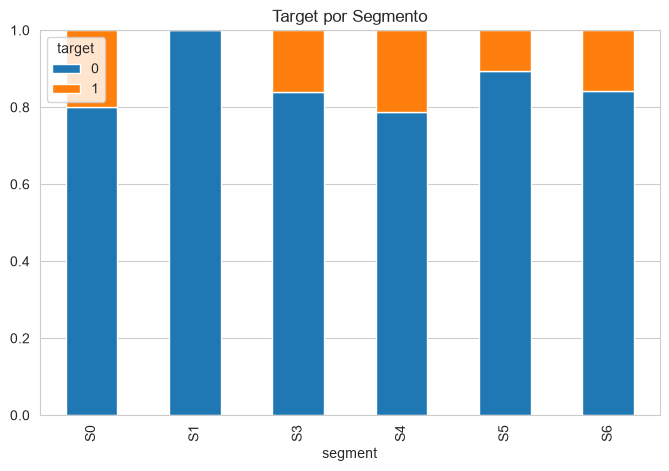

In [113]:
pd.crosstab(
    clientes["segment"],
    clientes["target"],
    normalize="index"
)
pd.crosstab(
    clientes["segment"],
    clientes["target"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Target por Segmento")
plt.show()

In [114]:
target_territory = pd.crosstab(
    clientes["territory_id"],
    clientes["target"],
    normalize="index"
)

target_territory[1].sort_values(ascending=False)

territory_id
T6    0.185606
T2    0.173664
T3    0.163848
T5    0.161100
T1    0.156654
T4    0.145299
Name: 1, dtype: float64

In [115]:
pd.crosstab(
    clientes["has_credit_line"],
    clientes["target"],
    normalize="index"
)

target,0,1
has_credit_line,,
0,0.829306,0.170694
1,0.845108,0.154892


In [116]:
pd.crosstab(
    clientes["has_marketing_impulse"],
    clientes["target"],
    normalize="index"
)

target,0,1
has_marketing_impulse,,
0,0.832997,0.167003
1,0.845592,0.154408


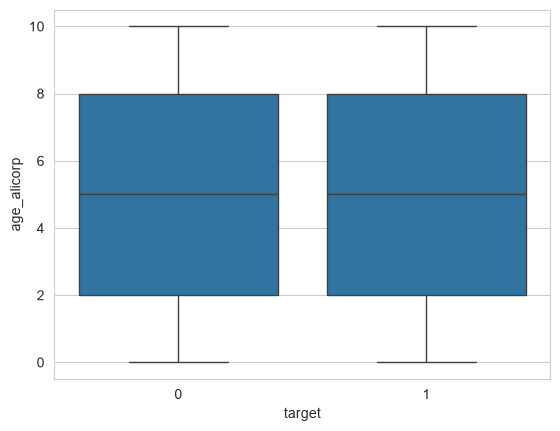

In [117]:
sns.boxplot(
    data=clientes,
    x="target",
    y="age_alicorp"
)

plt.show()

In [118]:
c_ventas=ventas["category_product"].nunique()
print(c_ventas)

10


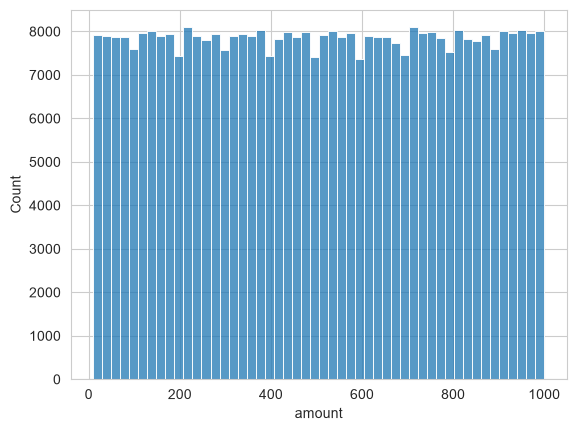

In [119]:
sns.histplot(
    ventas["amount"],
    bins=50
)

plt.show()

In [120]:
features_ventas = (
    ventas
    .groupby("customer_id")
    .agg(
        total_sales=("amount","sum"),
        avg_sales=("amount","mean"),
        max_sales=("amount","max"),
        purchase_count=("amount","count"),
        avg_discount=("discount","mean"),
        total_discount=("discount","sum"),
        unique_products=("product_id","nunique"),
        unique_categories=("category_product","nunique")
    )
    .reset_index()
)

In [121]:
df = clientes.merge(
    features_ventas,
    on="customer_id",
    how="left"
)

In [122]:
numericas = df.select_dtypes(
    include=["int64","float64"]
)

corr = numericas.corr()

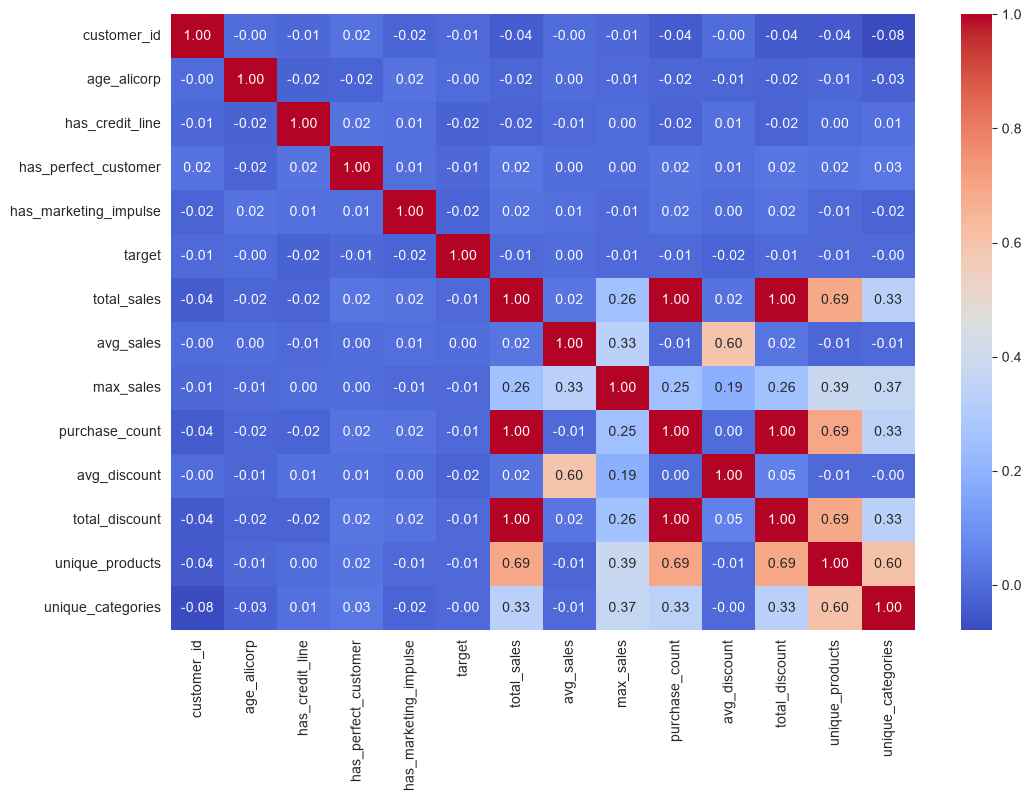

In [123]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

In [124]:
corr_target = (
    numericas
    .corr()["target"]
    .sort_values(ascending=False)
)

corr_target

target                   1.000000
avg_sales                0.002204
age_alicorp             -0.002407
unique_categories       -0.004283
total_sales             -0.005057
purchase_count          -0.005535
total_discount          -0.005582
unique_products         -0.006116
max_sales               -0.007487
customer_id             -0.007544
has_perfect_customer    -0.011621
has_marketing_impulse   -0.016152
avg_discount            -0.016434
has_credit_line         -0.021404
Name: target, dtype: float64

In [125]:
df.groupby("target").agg({
    "age_alicorp":"mean",
    "total_sales":"mean",
    "avg_sales":"mean",
    "purchase_count":"mean",
    "avg_discount":"mean",
    "unique_products":"mean",
    "unique_categories":"mean"
})

,age_alicorp,total_sales,avg_sales,purchase_count,avg_discount,unique_products,unique_categories
target,,,,,,,
0,5.047751,37857.623323,505.648824,74.948625,27.477681,33.647193,5.121846
1,5.027251,37133.196491,505.967918,73.383626,27.243684,33.183626,5.094737


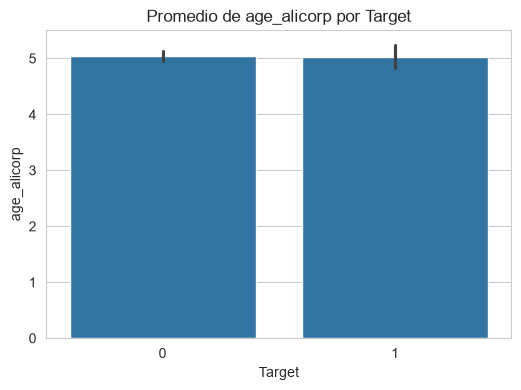

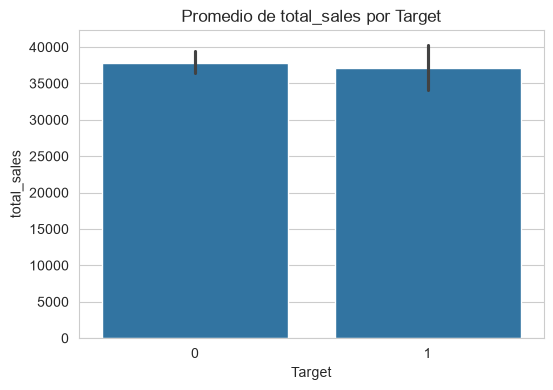

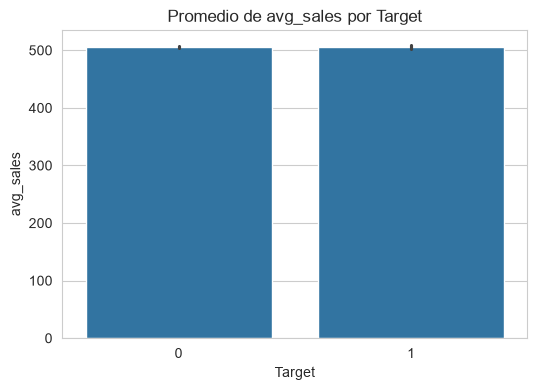

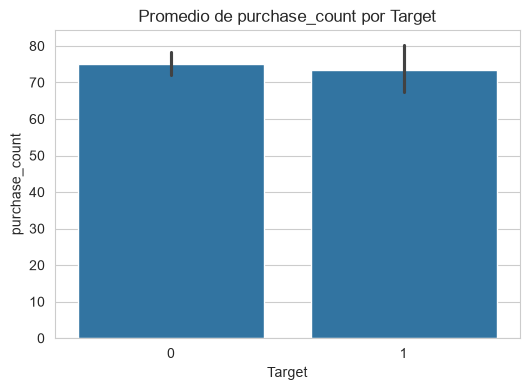

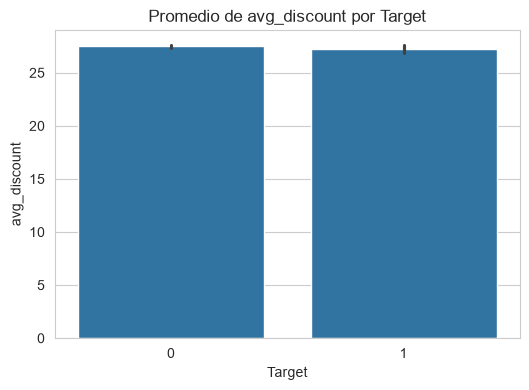

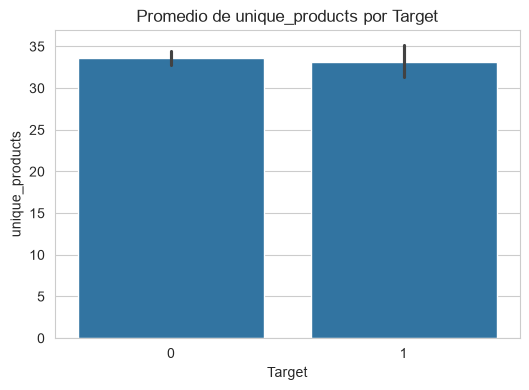

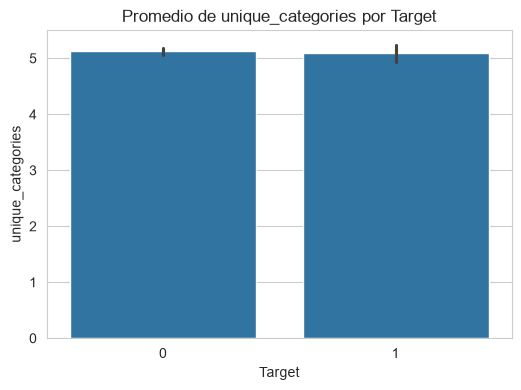

In [126]:
variables = [
    "age_alicorp",
    "total_sales",
    "avg_sales",
    "purchase_count",
    "avg_discount",
    "unique_products",
    "unique_categories"
]

for var in variables:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=df,
        x="target",
        y=var,
        estimator=np.mean
    )

    plt.title(f"Promedio de {var} por Target")
    plt.xlabel("Target")
    plt.ylabel(var)

    plt.show()

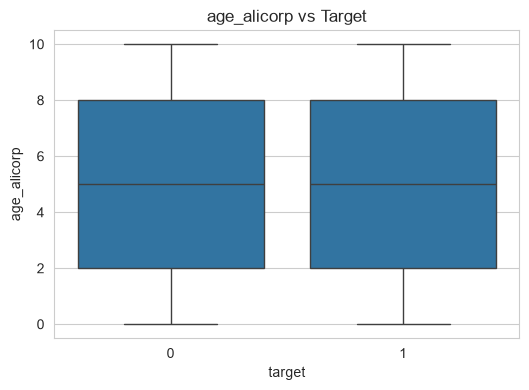

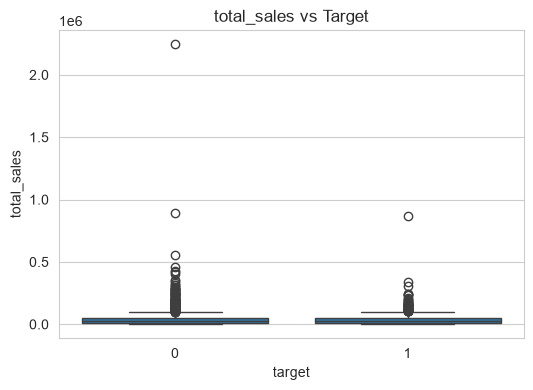

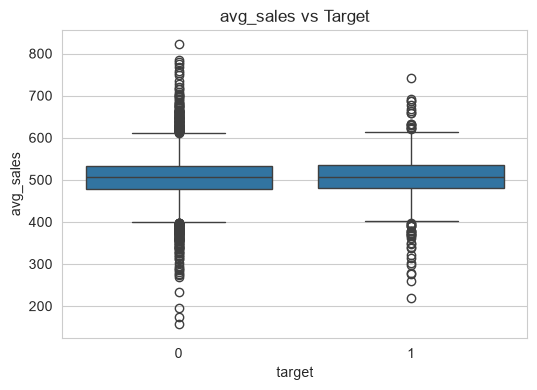

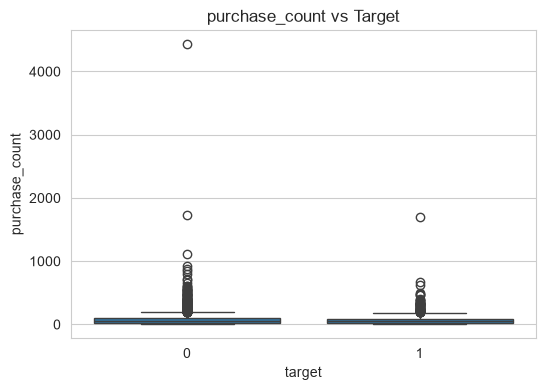

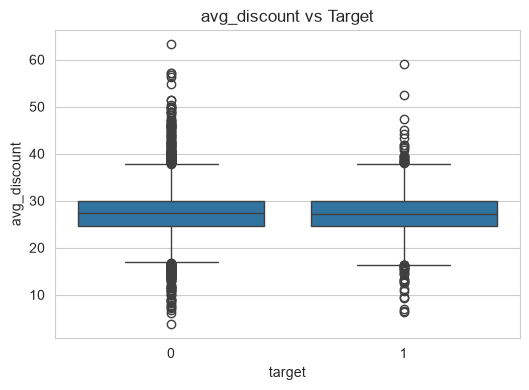

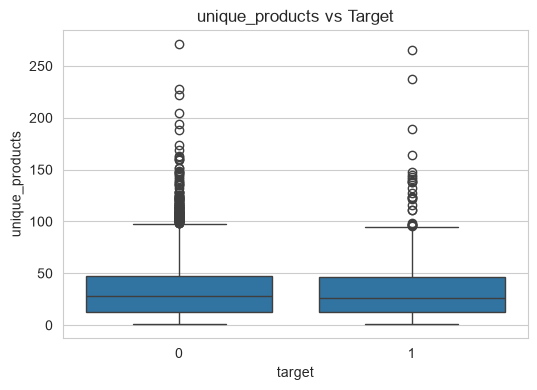

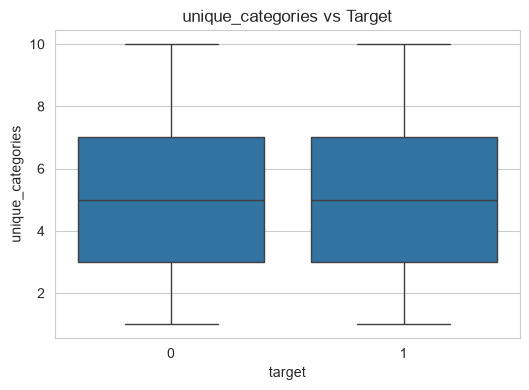

In [127]:
for var in variables:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="target",
        y=var
    )

    plt.title(f"{var} vs Target")

    plt.show()

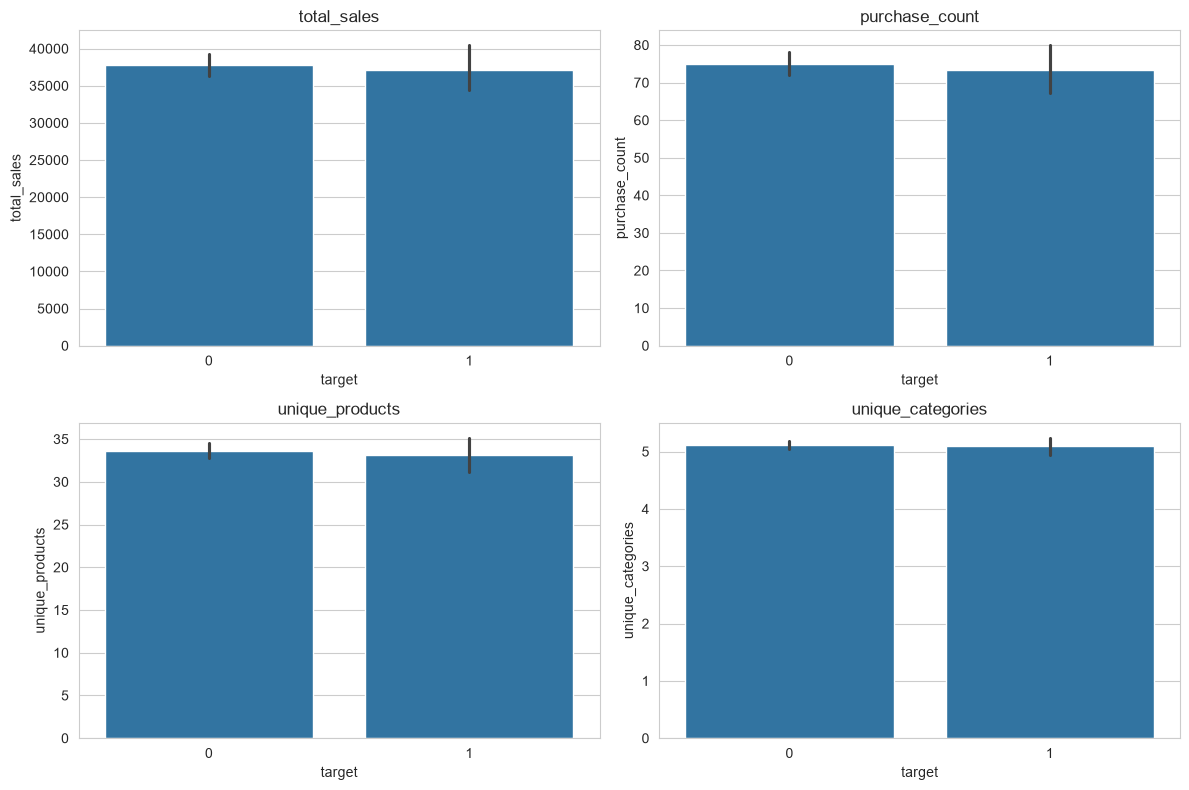

In [128]:
variables_negocio = [
    "total_sales",
    "purchase_count",
    "unique_products",
    "unique_categories"
]

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, var in zip(axes.flatten(), variables_negocio):

    sns.barplot(
        data=df,
        x="target",
        y=var,
        estimator=np.mean,
        ax=ax
    )

    ax.set_title(var)

plt.tight_layout()
plt.show()

<Axes: xlabel='target', ylabel='total_sales'>

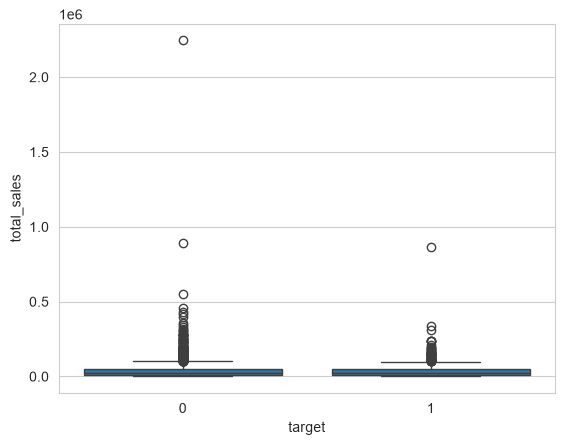

In [129]:
sns.boxplot(
    data=df,
    x="target",
    y="total_sales"
)

<Axes: xlabel='total_sales', ylabel='Count'>

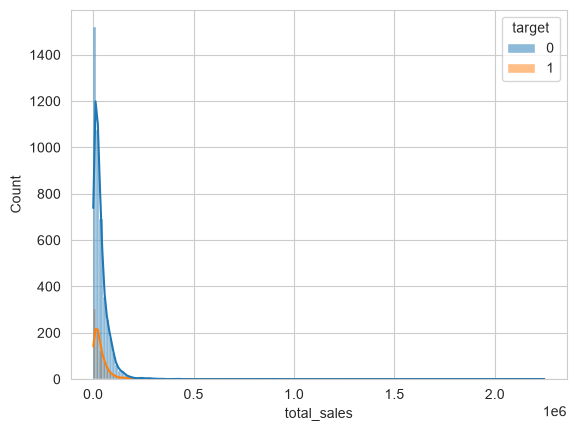

In [130]:
sns.histplot(
    data=df,
    x="total_sales",
    hue="target",
    kde=True
)

In [131]:
for col in [
    "has_credit_line",
    "has_perfect_customer",
    "has_marketing_impulse",
    "segment",
    "territory_id"
]:
    
    print("\n", col)
    
    print(
        pd.crosstab(
            df[col],
            df["target"],
            normalize="index"
        )
    )


 has_credit_line
target                  0         1
has_credit_line                    
0                0.829306  0.170694
1                0.845108  0.154892

 has_perfect_customer
target                       0         1
has_perfect_customer                    
0                     0.834237  0.165763
1                     0.843339  0.156661

 has_marketing_impulse
target                        0         1
has_marketing_impulse                    
0                      0.832997  0.167003
1                      0.845592  0.154408

 segment
target          0         1
segment                    
S0       0.801205  0.198795
S1       1.000000  0.000000
S3       0.838405  0.161595
S4       0.787879  0.212121
S5       0.894737  0.105263
S6       0.842475  0.157525

 territory_id
target               0         1
territory_id                    
T1            0.843346  0.156654
T2            0.826336  0.173664
T3            0.836152  0.163848
T4            0.854701  0.145299
T5          

In [132]:
df["segment"].value_counts()

segment
S3    4239
S6     711
S0     166
S4      99
S5      38
S1       1
Name: count, dtype: int64

In [133]:
territory_stats = pd.crosstab(
    df["territory_id"],
    df["target"]
)

territory_stats["total"] = territory_stats.sum(axis=1)

territory_stats["pct_target_1"] = (
    territory_stats[1] /
    territory_stats["total"]
)

territory_stats.sort_values(
    "pct_target_1",
    ascending=False
)

target,0,1,total,pct_target_1
territory_id,,,,
T6,430,98,528,0.185606
T2,433,91,524,0.173664
T3,791,155,946,0.163848
T5,427,82,509,0.161100
T1,2218,412,2630,0.156654
T4,100,17,117,0.145299


In [134]:
features_ventas = (
    ventas
    .groupby("customer_id")
    .agg(
        total_sales=("amount","sum"),
        avg_sales=("amount","mean"),
        max_sales=("amount","max"),
        min_sales=("amount","min"),
        std_amount=("amount","std"),

        purchase_count=("amount","count"),

        avg_discount=("discount","mean"),
        max_discount=("discount","max"),
        min_discount=("discount","min"),
        std_discount=("discount","std"),
        total_discount=("discount","sum"),
        unique_products=("product_id","nunique"),
        unique_categories=("category_product","nunique")
    )
    .reset_index()
)

In [135]:
features_ventas["sales_per_purchase"] = (
    features_ventas["total_sales"]
    / features_ventas["purchase_count"]
)

features_ventas["sales_per_product"] = (
    features_ventas["total_sales"]
    / features_ventas["unique_products"]
)

features_ventas["products_per_category"] = (
    features_ventas["unique_products"]
    / features_ventas["unique_categories"]
)

features_ventas["discount_per_purchase"] = (
    features_ventas["avg_discount"]
)

In [136]:
features_ventas["cv_amount"] = (
    features_ventas["std_amount"]
    / features_ventas["avg_sales"]
)

features_ventas["cv_discount"] = (
    features_ventas["std_discount"]
    / features_ventas["avg_discount"]
)

features_ventas["sales_per_category"] = (
    features_ventas["total_sales"]
    / features_ventas["unique_categories"]
)


features_ventas["category_product_ratio"] = (
    features_ventas["unique_categories"]
    / features_ventas["unique_products"]
)

In [137]:
ventas["date"] = pd.to_datetime(
    ventas["date"],
    unit="D",
    origin="1899-12-30"
)

In [138]:
fecha_max = ventas["date"].max()

recency = (
    ventas.groupby("customer_id")
    .agg(
        last_purchase=("date","max")
    )
    .reset_index()
)

recency["days_since_last_purchase"] = (
    fecha_max - recency["last_purchase"]
).dt.days

In [139]:
lifespan = (
    ventas.groupby("customer_id")
    .agg(
        first_purchase=("date","min"),
        last_purchase=("date","max")
    )
    .reset_index()
)

lifespan["customer_lifespan"] = (
    lifespan["last_purchase"]
    - lifespan["first_purchase"]
).dt.days

In [140]:
lifespan["purchases_per_day"] = (
    features_ventas["purchase_count"]
    / lifespan["customer_lifespan"].replace(0,1)
)

In [141]:
cat_favorita = (
    ventas.groupby(
        ["customer_id","category_product"]
    )
    .size()
    .reset_index(name="n")
)

cat_favorita = (
    cat_favorita
    .sort_values(
        ["customer_id","n"],
        ascending=[True,False]
    )
    .drop_duplicates("customer_id")
)

In [142]:
from scipy.stats import entropy

def calc_entropy(grupo):
    p = grupo.value_counts(normalize=True)
    return entropy(p)

entropy_df = (
    ventas.groupby("customer_id")["category_product"]
    .apply(calc_entropy)
    .reset_index(name="category_entropy")
)

In [143]:
product_entropy = (
    ventas.groupby("customer_id")["product_id"]
    .apply(calc_entropy)
    .reset_index(name="product_entropy")
)

In [144]:
features_ventas["discount_ratio"] = (
    features_ventas["total_discount"]
    / features_ventas["total_sales"]
)

In [145]:
df_model = clientes.merge(
    features_ventas,
    on="customer_id",
    how="left"
)

df_model = df_model.merge(
    recency[["customer_id","days_since_last_purchase"]],
    on="customer_id",
    how="left"
)

df_model = df_model.merge(
    entropy_df,
    on="customer_id",
    how="left"
)

df_model = df_model.merge(
    product_entropy,
    on="customer_id",
    how="left"
)

In [146]:
corr_target = (
    df_model
    .select_dtypes(include=np.number)
    .corr()["target"]
    .sort_values(ascending=False)
)

print(corr_target.head(20))

target                      1.000000
days_since_last_purchase    0.015908
cv_discount                 0.011918
product_entropy             0.002407
sales_per_purchase          0.002204
avg_sales                   0.002204
category_entropy            0.000643
products_per_category       0.000158
age_alicorp                -0.002407
sales_per_category         -0.004027
unique_categories          -0.004283
std_amount                 -0.004809
total_sales                -0.005057
cv_amount                  -0.005136
purchase_count             -0.005535
total_discount             -0.005582
unique_products            -0.006116
max_sales                  -0.007487
customer_id                -0.007544
max_discount               -0.008351
Name: target, dtype: float64


In [147]:
segment_stats = (
    df_model
    .groupby("segment")
    .agg(
        clientes=("customer_id","count"),
        potencial=("target","mean")
    )
    .sort_values("potencial", ascending=False)
)

segment_stats

,clientes,potencial
segment,,
S4,99,0.212121
S0,166,0.198795
S3,4239,0.161595
S6,711,0.157525
S5,38,0.105263
S1,1,0.000000


In [148]:
territory_stats = (
    df_model
    .groupby("territory_id")
    .agg(
        clientes=("customer_id","count"),
        potencial=("target","mean")
    )
    .sort_values("potencial", ascending=False)
)

territory_stats

,clientes,potencial
territory_id,,
T6,528,0.185606
T2,524,0.173664
T3,946,0.163848
T5,509,0.161100
T1,2630,0.156654
T4,117,0.145299


In [149]:
df_model.columns

Index(['customer_id', 'territory_id', 'segment', 'age_alicorp',
       'has_credit_line', 'has_perfect_customer', 'has_marketing_impulse',
       'target', 'total_sales', 'avg_sales', 'max_sales', 'min_sales',
       'std_amount', 'purchase_count', 'avg_discount', 'max_discount',
       'min_discount', 'std_discount', 'total_discount', 'unique_products',
       'unique_categories', 'sales_per_purchase', 'sales_per_product',
       'products_per_category', 'discount_per_purchase', 'cv_amount',
       'cv_discount', 'sales_per_category', 'category_product_ratio',
       'discount_ratio', 'days_since_last_purchase', 'category_entropy',
       'product_entropy'],
      dtype='str')

In [150]:
X = df_model.drop(
    columns=[
        "customer_id",
        "target"
    ]
)

y = df_model["target"]

In [151]:
X = pd.get_dummies(
    X,
    columns=[
        "segment",
        "territory_id"
    ],
    drop_first=True
)

In [152]:
X.isnull().sum().sort_values(ascending=False).head(20)

age_alicorp              75
has_credit_line           0
has_perfect_customer      0
has_marketing_impulse     0
total_sales               0
avg_sales                 0
max_sales                 0
min_sales                 0
std_amount                0
purchase_count            0
avg_discount              0
max_discount              0
min_discount              0
std_discount              0
total_discount            0
unique_products           0
unique_categories         0
sales_per_purchase        0
sales_per_product         0
products_per_category     0
dtype: int64

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [154]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [155]:
y_pred = rf.predict(X_test)

y_proba = rf.predict_proba(X_test)[:,1]

In [156]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print(roc_auc)

0.48720760233918126


In [157]:
X = df_model.drop(
    columns=[
        "customer_id",
        "target"
    ]
)

y = df_model["target"]

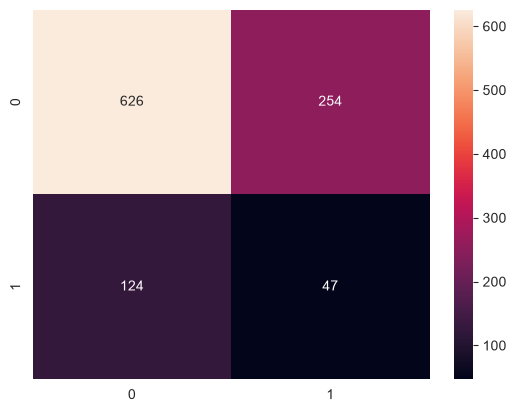

In [158]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [159]:
X = df_model.drop(columns=["customer_id", "target"])
y = df_model["target"]

X = pd.get_dummies(
    X,
    columns=["segment", "territory_id"],
    drop_first=True
)

X = X.fillna(0)

In [160]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("AUC por fold:")
print(scores)

print("\nAUC promedio:")
print(scores.mean())

print("\nDesviación:")
print(scores.std())

AUC por fold:
[0.51448033 0.51384237 0.5181353  0.47856194 0.48360378]

AUC promedio:
0.5017247424850263

Desviación:
0.01699254776817761


In [161]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.fit(X, y).feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
8,std_amount,0.060245
21,cv_amount,0.055008
28,product_entropy,0.048879
18,sales_per_product,0.047300
22,cv_discount,0.046963
5,avg_sales,0.043545
25,discount_ratio,0.042919
27,category_entropy,0.042717
4,total_sales,0.042259
23,sales_per_category,0.042223


In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores.mean())

c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    htt

0.4800251497067555


c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    htt

[0.48180489 0.5068647  0.45553562 0.46514487 0.49077567]
0.4800251497067555


c:\Users\JCotrina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [164]:
importance = importance.sort_values(
    "importance",
    ascending=False
)

top20 = importance["feature"].head(20).tolist()

X_top = X[top20]

In [165]:
scores = cross_val_score(
    rf,
    X_top,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores.mean())

0.49141483543899567


In [166]:
X.columns


Index(['age_alicorp', 'has_credit_line', 'has_perfect_customer',
       'has_marketing_impulse', 'total_sales', 'avg_sales', 'max_sales',
       'min_sales', 'std_amount', 'purchase_count', 'avg_discount',
       'max_discount', 'min_discount', 'std_discount', 'total_discount',
       'unique_products', 'unique_categories', 'sales_per_purchase',
       'sales_per_product', 'products_per_category', 'discount_per_purchase',
       'cv_amount', 'cv_discount', 'sales_per_category',
       'category_product_ratio', 'discount_ratio', 'days_since_last_purchase',
       'category_entropy', 'product_entropy', 'segment_S1', 'segment_S3',
       'segment_S4', 'segment_S5', 'segment_S6', 'territory_id_T2',
       'territory_id_T3', 'territory_id_T4', 'territory_id_T5',
       'territory_id_T6'],
      dtype='str')

In [167]:
customer_cols = [
    "age_alicorp",
    "has_credit_line",
    "has_perfect_customer",
    "has_marketing_impulse",
    "segment",
    "territory_id"
]

X_customer = df_model[customer_cols]

X_customer = pd.get_dummies(
    X_customer,
    columns=["segment", "territory_id"],
    drop_first=True
)

scores = cross_val_score(
    rf,
    X_customer,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.49690324 0.49149389 0.50970893 0.47992757 0.4503057 ]
0.4856678658629889


In [168]:
transaction_cols = [
    c for c in X.columns
    if c not in X_customer.columns
]

X_transaction = X[transaction_cols]

scores = cross_val_score(
    rf,
    X_transaction,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores.mean())

0.4876968142595949


In [169]:
import pandas as pd

# Asegurar formato fecha
ventas["date"] = pd.to_datetime(ventas["date"])

# Fecha más reciente del dataset
fecha_max = ventas["date"].max()

# ==========================
# VENTAS RECIENTES
# ==========================

ventas_30d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=30)
    ]
    .groupby("customer_id")["amount"]
    .sum()
    .rename("sales_30d")
)

ventas_90d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=90)
    ]
    .groupby("customer_id")["amount"]
    .sum()
    .rename("sales_90d")
)

ventas_180d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=180)
    ]
    .groupby("customer_id")["amount"]
    .sum()
    .rename("sales_180d")
)

# ==========================
# FRECUENCIA RECIENTE
# ==========================

compras_30d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=30)
    ]
    .groupby("customer_id")
    .size()
    .rename("purchases_30d")
)

compras_90d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=90)
    ]
    .groupby("customer_id")
    .size()
    .rename("purchases_90d")
)

# ==========================
# PRODUCTOS RECIENTES
# ==========================

productos_30d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=30)
    ]
    .groupby("customer_id")["product_id"]
    .nunique()
    .rename("products_30d")
)

productos_hist = (
    ventas
    .groupby("customer_id")["product_id"]
    .nunique()
    .rename("products_hist")
)

ratio_productos = (
    pd.concat(
        [productos_30d, productos_hist],
        axis=1
    )
    .fillna(0)
)

ratio_productos["products_30d_ratio"] = (
    ratio_productos["products_30d"]
    /
    ratio_productos["products_hist"].replace(0, 1)
)

# ==========================
# CATEGORIAS RECIENTES
# ==========================

categorias_30d = (
    ventas[
        ventas["date"] >= fecha_max - pd.Timedelta(days=30)
    ]
    .groupby("customer_id")["category_product"]
    .nunique()
    .rename("categories_30d")
)

categorias_hist = (
    ventas
    .groupby("customer_id")["category_product"]
    .nunique()
    .rename("categories_hist")
)

ratio_categorias = (
    pd.concat(
        [categorias_30d, categorias_hist],
        axis=1
    )
    .fillna(0)
)

ratio_categorias["categories_30d_ratio"] = (
    ratio_categorias["categories_30d"]
    /
    ratio_categorias["categories_hist"].replace(0, 1)
)

# ==========================
# CRECIMIENTO
# ==========================

ventas_recientes = pd.concat(
    [
        ventas_30d,
        ventas_90d,
        ventas_180d
    ],
    axis=1
).fillna(0)

ventas_recientes["growth_30_90"] = (
    ventas_recientes["sales_30d"]
    /
    ventas_recientes["sales_90d"].replace(0, 1)
)

ventas_hist = (
    ventas
    .groupby("customer_id")["amount"]
    .sum()
    .rename("sales_hist")
)

ventas_recientes = ventas_recientes.join(
    ventas_hist,
    how="left"
)

ventas_recientes["recent_vs_hist"] = (
    ventas_recientes["sales_30d"]
    /
    ventas_recientes["sales_hist"].replace(0, 1)
)

# ==========================
# DATASET FINAL FEATURES
# ==========================

nuevas_features = pd.concat(
    [
        ventas_recientes,
        compras_30d,
        compras_90d,
        ratio_productos[["products_30d_ratio"]],
        ratio_categorias[["categories_30d_ratio"]]
    ],
    axis=1
).fillna(0)

print(nuevas_features.head())

             sales_30d  sales_90d  sales_180d  growth_30_90  sales_hist  \
customer_id                                                               
1              11472.0      75848      153167      0.151250      153167   
2             303592.0    1047357     2245743      0.289865     2245743   
3              38351.0     122912      285946      0.312020      285946   
4              20514.0     243004      258438      0.084418      258438   
5              14969.0      32989       45812      0.453757       45812   

             recent_vs_hist  purchases_30d  purchases_90d  products_30d_ratio  \
customer_id                                                                     
1                  0.074899           21.0            160            0.173913   
2                  0.135186          580.0           2088            0.723404   
3                  0.134120           71.0            240            0.674419   
4                  0.079377           39.0            473            

In [170]:
df_model = df_model.merge(
    nuevas_features,
    on="customer_id",
    how="left"
)

df_model = df_model.fillna(0)

In [171]:
print(df_model.columns.tolist())

['customer_id', 'territory_id', 'segment', 'age_alicorp', 'has_credit_line', 'has_perfect_customer', 'has_marketing_impulse', 'target', 'total_sales', 'avg_sales', 'max_sales', 'min_sales', 'std_amount', 'purchase_count', 'avg_discount', 'max_discount', 'min_discount', 'std_discount', 'total_discount', 'unique_products', 'unique_categories', 'sales_per_purchase', 'sales_per_product', 'products_per_category', 'discount_per_purchase', 'cv_amount', 'cv_discount', 'sales_per_category', 'category_product_ratio', 'discount_ratio', 'days_since_last_purchase', 'category_entropy', 'product_entropy', 'sales_30d', 'sales_90d', 'sales_180d', 'growth_30_90', 'sales_hist', 'recent_vs_hist', 'purchases_30d', 'purchases_90d', 'products_30d_ratio', 'categories_30d_ratio']


In [172]:
# Variables predictoras
X = df_model.drop(
    columns=[
        "customer_id",
        "target"
    ]
)

# Variable objetivo
y = df_model["target"]

# One Hot Encoding
X = pd.get_dummies(
    X,
    columns=["segment", "territory_id"],
    drop_first=True
)

X = X.fillna(0)

print(X.shape)

(5254, 49)


In [173]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print("AUC:", auc)

AUC: 0.46978335991493886


In [174]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("AUC por fold:")
print(scores)

print("\nAUC promedio:")
print(scores.mean())

print("\nDesviación:")
print(scores.std())

AUC por fold:
[0.52676103 0.5206672  0.54286284 0.48597156 0.48450858]

AUC promedio:
0.5121542410513131

Desviación:
0.02314589504075979


In [175]:
rf.fit(X, y)

importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(30))

                     feature  importance
8                 std_amount    0.046587
21                 cv_amount    0.042294
28           product_entropy    0.038497
25            discount_ratio    0.036620
22               cv_discount    0.035151
32              growth_30_90    0.034875
18         sales_per_product    0.034036
17        sales_per_purchase    0.033773
29                 sales_30d    0.033284
30                 sales_90d    0.031898
5                  avg_sales    0.031513
13              std_discount    0.030881
14            total_discount    0.030472
27          category_entropy    0.030460
34            recent_vs_hist    0.028864
20     discount_per_purchase    0.028819
10              avg_discount    0.028211
33                sales_hist    0.027655
37        products_30d_ratio    0.027106
23        sales_per_category    0.026652
4                total_sales    0.026528
31                sales_180d    0.026110
6                  max_sales    0.025203
15           uni

In [176]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1 por fold:")
print(scores)

print("\nF1 promedio:")
print(scores.mean())

print("\nDesviación:")
print(scores.std())

F1 por fold:
[0.         0.         0.         0.01156069 0.        ]

F1 promedio:
0.002312138728323699

Desviación:
0.004624277456647398


In [177]:
# Definimos una ventana de comparación, por ejemplo 30 días
N = 7

fecha_max = ventas["date"].max()
fecha_corte = fecha_max - pd.Timedelta(days=N)
fecha_inicio_anterior = fecha_corte - pd.Timedelta(days=N)

# Periodo reciente: últimos N días
ventas_recientes = (
    ventas[ventas["date"] > fecha_corte]
    .groupby("customer_id")
    .agg(sales_recent=("amount", "sum"), purchases_recent=("amount", "count"))
    .reset_index()
)

# Periodo anterior: los N días antes del periodo reciente
ventas_previas = (
    ventas[(ventas["date"] > fecha_inicio_anterior) & (ventas["date"] <= fecha_corte)]
    .groupby("customer_id")
    .agg(sales_previous=("amount", "sum"), purchases_previous=("amount", "count"))
    .reset_index()
)

trend = ventas_recientes.merge(ventas_previas, on="customer_id", how="outer").fillna(0)

# Delta absoluto y % de crecimiento
trend["sales_trend_abs"] = trend["sales_recent"] - trend["sales_previous"]

trend["sales_trend_pct"] = (
    (trend["sales_recent"] - trend["sales_previous"])
    / trend["sales_previous"].replace(0, np.nan)
)
trend["sales_trend_pct"] = trend["sales_trend_pct"].fillna(0)

trend["purchases_trend_abs"] = trend["purchases_recent"] - trend["purchases_previous"]

# Clasificación simple de la tendencia (útil para EDA, no necesariamente para el modelo)
trend["trend_direction"] = np.select(
    [trend["sales_trend_abs"] > 0, trend["sales_trend_abs"] < 0],
    ["crece", "decrece"],
    default="estable"
)

trend.head()

,customer_id,sales_recent,purchases_recent,sales_previous,purchases_previous,sales_trend_abs,sales_trend_pct,purchases_trend_abs,trend_direction
0,1,1473.0,2.0,6876.0,12.0,-5403.0,-0.785777,-10.0,decrece
1,2,22125.0,44.0,84127.0,153.0,-62002.0,-0.737005,-109.0,decrece
2,6,0.0,0.0,13062.0,23.0,-13062.0,-1.000000,-23.0,decrece
3,7,9088.0,18.0,0.0,0.0,9088.0,0.000000,18.0,crece
4,8,31641.0,56.0,0.0,0.0,31641.0,0.000000,56.0,crece


In [178]:
ventas["date"]

0        2020-07-14
1        2020-07-14
2        2020-07-14
3        2020-07-14
4        2020-07-14
            ...    
392437   2020-12-03
392438   2020-12-07
392439   2020-12-02
392440   2020-12-08
392441   2020-12-07
Name: date, Length: 392442, dtype: datetime64[s]

In [179]:
print(ventas["date"].min(), ventas["date"].max())
print((ventas["date"].max() - ventas["date"].min()).days, "días de historia")

2020-07-14 00:00:00 2020-12-12 00:00:00
151 días de historia


In [180]:
# Primero necesitas total_sales por cliente ya unido a segmento/territorio
base = df_model[["customer_id", "segment", "territory_id", "total_sales", "purchase_count"]].copy()

# Promedio del grupo (excluyendo NaN, que ya deberían estar imputados)
seg_mean = base.groupby("segment")["total_sales"].transform("mean")
terr_mean = base.groupby("territory_id")["total_sales"].transform("mean")

seg_mean_purch = base.groupby("segment")["purchase_count"].transform("mean")

relative_feats = pd.DataFrame({
    "customer_id": base["customer_id"],
    "gap_vs_segment": base["total_sales"] - seg_mean,
    "gap_vs_segment_pct": (base["total_sales"] - seg_mean) / seg_mean.replace(0, np.nan),
    "gap_vs_territory": base["total_sales"] - terr_mean,
    "purchase_gap_vs_segment": base["purchase_count"] - seg_mean_purch,
})

relative_feats = relative_feats.fillna(0)

relative_feats.head()

,customer_id,gap_vs_segment,gap_vs_segment_pct,gap_vs_territory,purchase_gap_vs_segment
0,1,1.143487e+05,2.945747,1.151586e+05,240.142722
1,2,2.206925e+06,56.852759,2.205244e+06,4355.142722
2,3,2.471277e+05,6.366277,2.479376e+05,482.142722
3,4,2.196197e+05,5.657641,2.204296e+05,426.142722
4,5,6.993747e+03,0.180166,7.803604e+03,21.142722


In [181]:
df_model_v2 = df_model.merge(trend, on="customer_id", how="left")
df_model_v2 = df_model_v2.merge(relative_feats, on="customer_id", how="left")

df_model_v2 = df_model_v2.fillna(0)

corr_target_v2 = (
    df_model_v2
    .select_dtypes(include=np.number)
    .corr()["target"]
    .sort_values(ascending=False)
)

print(corr_target_v2.head(15))
print(corr_target_v2.tail(15))

target                      1.000000
days_since_last_purchase    0.015908
cv_discount                 0.011918
sales_30d                   0.006130
purchases_30d               0.005169
purchases_trend_abs         0.004819
sales_trend_abs             0.004043
product_entropy             0.002407
purchases_recent            0.002255
avg_sales                   0.002204
sales_per_purchase          0.002204
sales_recent                0.001115
growth_30_90                0.001025
category_entropy            0.000643
products_per_category       0.000158
Name: target, dtype: float64
customer_id              -0.007544
max_discount             -0.008351
min_sales                -0.008801
has_perfect_customer     -0.011621
products_30d_ratio       -0.011957
category_product_ratio   -0.012763
std_discount             -0.014639
min_discount             -0.015287
sales_per_product        -0.015474
has_marketing_impulse    -0.016152
avg_discount             -0.016434
discount_per_purchase    -0.016

In [182]:
X_v2 = df_model_v2.drop(columns=["customer_id", "target", "trend_direction"])
X_v2 = pd.get_dummies(X_v2, columns=["segment", "territory_id"], drop_first=True)
X_v2 = X_v2.fillna(0)

scores_v2 = cross_val_score(
    rf, X_v2, y, cv=cv, scoring="roc_auc", n_jobs=-1
)

print("AUC con features nuevas:", scores_v2.mean(), "+/-", scores_v2.std())

AUC con features nuevas: 0.5130370633464759 +/- 0.02231872281375311


In [183]:
X_v2.columns

Index(['age_alicorp', 'has_credit_line', 'has_perfect_customer',
       'has_marketing_impulse', 'total_sales', 'avg_sales', 'max_sales',
       'min_sales', 'std_amount', 'purchase_count', 'avg_discount',
       'max_discount', 'min_discount', 'std_discount', 'total_discount',
       'unique_products', 'unique_categories', 'sales_per_purchase',
       'sales_per_product', 'products_per_category', 'discount_per_purchase',
       'cv_amount', 'cv_discount', 'sales_per_category',
       'category_product_ratio', 'discount_ratio', 'days_since_last_purchase',
       'category_entropy', 'product_entropy', 'sales_30d', 'sales_90d',
       'sales_180d', 'growth_30_90', 'sales_hist', 'recent_vs_hist',
       'purchases_30d', 'purchases_90d', 'products_30d_ratio',
       'categories_30d_ratio', 'sales_recent', 'purchases_recent',
       'sales_previous', 'purchases_previous', 'sales_trend_abs',
       'sales_trend_pct', 'purchases_trend_abs', 'gap_vs_segment',
       'gap_vs_segment_pct', 'gap_

In [184]:
# ¿Se perdieron o duplicaron clientes en los merges?
print(clientes.shape[0], df_model.shape[0])
print(df_model["customer_id"].duplicated().sum())

# ¿El target sigue igual de balanceado después de todos los merges?
print(df_model["target"].value_counts(normalize=True))

# ¿Cuántos customer_id de "clientes" no tienen NINGUNA transacción?
sin_transacciones = clientes[~clientes["customer_id"].isin(ventas["customer_id"])]
print(sin_transacciones.shape[0], "clientes sin transacciones")
print(sin_transacciones["target"].value_counts(normalize=True))

5254 5254
0
target
0    0.837267
1    0.162733
Name: proportion, dtype: float64
0 clientes sin transacciones
Series([], Name: proportion, dtype: float64)


In [185]:
from sklearn.metrics import roc_auc_score

numericas = df_model_v2.select_dtypes(include=np.number).drop(columns=["target", "customer_id"])

resultados = {}
for col in numericas.columns:
    vals = numericas[col].fillna(numericas[col].median())
    try:
        auc = roc_auc_score(y, vals)
        # si da menos de 0.5, invertimos (la relación es inversa, pero igual de informativa)
        auc = max(auc, 1 - auc)
        resultados[col] = auc
    except Exception:
        pass

pd.Series(resultados).sort_values(ascending=False)

discount_ratio              0.517793
cv_amount                   0.515732
max_sales                   0.514702
has_credit_line             0.514496
categories_30d_ratio        0.512800
sales_per_purchase          0.511418
avg_sales                   0.511418
purchases_90d               0.511037
std_discount                0.510957
has_marketing_impulse       0.510357
purchases_30d               0.510202
std_amount                  0.509693
sales_per_product           0.509476
total_discount              0.508837
sales_90d                   0.508795
sales_trend_pct             0.508490
sales_30d                   0.508303
sales_per_category          0.508076
purchase_count              0.507808
gap_vs_territory            0.507491
products_30d_ratio          0.507476
has_perfect_customer        0.507418
unique_products             0.507401
product_entropy             0.507391
max_discount                0.507205
total_sales                 0.506446
sales_hist                  0.506446
s

In [186]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Modelo deliberadamente SIN regularización, máxima flexibilidad
xgb_overfit = XGBClassifier(
    n_estimators=1000,
    max_depth=10,          # mucho más profundo que el original (max_depth=3)
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=1,
    eval_metric="logloss",
    random_state=42
)

xgb_overfit.fit(X_v2, y)
y_proba_train = xgb_overfit.predict_proba(X_v2)[:, 1]

print("AUC en TRAIN (memorización forzada):", roc_auc_score(y, y_proba_train))

AUC en TRAIN (memorización forzada): 1.0


In [187]:
X_v2.columns

Index(['age_alicorp', 'has_credit_line', 'has_perfect_customer',
       'has_marketing_impulse', 'total_sales', 'avg_sales', 'max_sales',
       'min_sales', 'std_amount', 'purchase_count', 'avg_discount',
       'max_discount', 'min_discount', 'std_discount', 'total_discount',
       'unique_products', 'unique_categories', 'sales_per_purchase',
       'sales_per_product', 'products_per_category', 'discount_per_purchase',
       'cv_amount', 'cv_discount', 'sales_per_category',
       'category_product_ratio', 'discount_ratio', 'days_since_last_purchase',
       'category_entropy', 'product_entropy', 'sales_30d', 'sales_90d',
       'sales_180d', 'growth_30_90', 'sales_hist', 'recent_vs_hist',
       'purchases_30d', 'purchases_90d', 'products_30d_ratio',
       'categories_30d_ratio', 'sales_recent', 'purchases_recent',
       'sales_previous', 'purchases_previous', 'sales_trend_abs',
       'sales_trend_pct', 'purchases_trend_abs', 'gap_vs_segment',
       'gap_vs_segment_pct', 'gap_

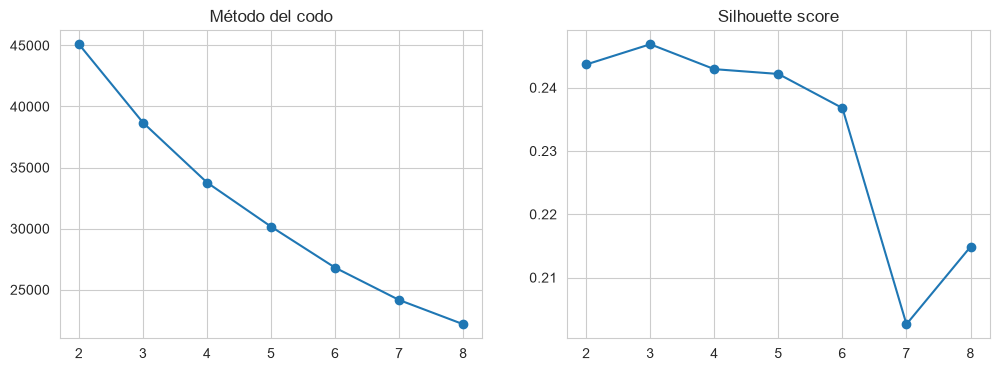

In [188]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Usamos solo las features de comportamiento (sin target, sin IDs)
cluster_cols = [
    "total_sales", "avg_sales", "purchase_count", "avg_discount",
    "unique_products", "unique_categories", "days_since_last_purchase",
    "sales_trend_pct", "gap_vs_segment", "category_entropy", "product_entropy"
]

X_cluster = df_model_v2[cluster_cols].fillna(0)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Buscar el número de clusters con método del codo + silhouette
inertias = []
silhouettes = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(rango_k, inertias, marker="o")
ax[0].set_title("Método del codo")
ax[1].plot(rango_k, silhouettes, marker="o")
ax[1].set_title("Silhouette score")
plt.show()

In [189]:
k_elegido = 4  # ajusta según el gráfico

kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df_model_v2["cluster"] = kmeans.fit_predict(X_cluster_scaled)

# La prueba clave: ¿algún cluster tiene tasa de target distinta?
cluster_stats = (
    df_model_v2
    .groupby("cluster")
    .agg(
        clientes=("customer_id", "count"),
        tasa_target=("target", "mean"),
        ticket_promedio=("total_sales", "mean")
    )
    .sort_values("tasa_target", ascending=False)
)

print(cluster_stats)

         clientes  tasa_target  ticket_promedio
cluster                                        
2            2925     0.166496     3.039007e+04
1            1512     0.164021     1.238389e+04
0             816     0.147059     1.083621e+05
3               1     0.000000     2.245743e+06


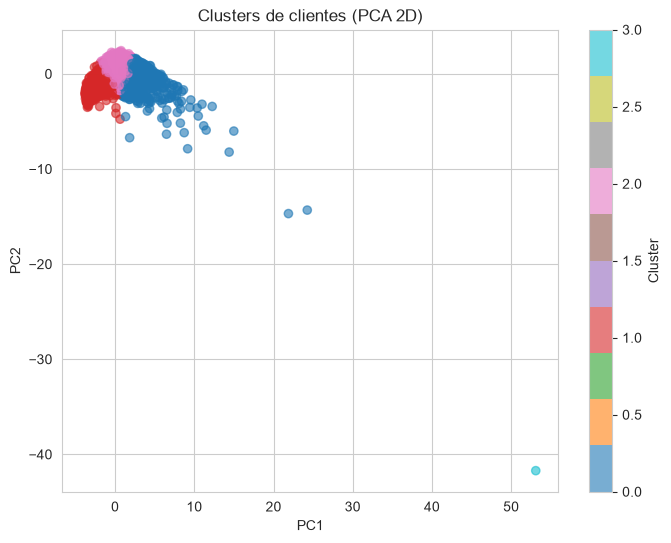

In [190]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=df_model_v2["cluster"], cmap="tab10", alpha=0.6)
plt.title("Clusters de clientes (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [191]:
print("Rango de fechas:", ventas["date"].min(), "a", ventas["date"].max())
print("Total de días:", (ventas["date"].max() - ventas["date"].min()).days)

ventas["year_month"] = ventas["date"].dt.to_period("M")
print("Meses distintos en el dataset:", ventas["year_month"].nunique())

# Cuántos meses de historia tiene cada cliente en promedio
meses_por_cliente = ventas.groupby("customer_id")["year_month"].nunique()
print(meses_por_cliente.describe())

Rango de fechas: 2020-07-14 00:00:00 a 2020-12-12 00:00:00
Total de días: 151
Meses distintos en el dataset: 6
count    5254.000000
mean        4.930719
std         0.800816
min         4.000000
25%         4.000000
50%         5.000000
75%         6.000000
max         6.000000
Name: year_month, dtype: float64


In [192]:
ventas["year_week"] = ventas["date"].dt.to_period("W")

panel_semanal = (
    ventas
    .groupby(["customer_id", "year_week"])
    .agg(
        sales_semana=("amount", "sum"),
        compras_semana=("amount", "count"),
        descuento_semana=("discount", "sum"),
        descuento_mayor_cero=("discount", lambda x: (x > 0).sum())
    )
    .reset_index()
)

panel_semanal["neto_semana"] = (
    panel_semanal["sales_semana"] - panel_semanal["descuento_semana"]
)

panel_semanal.head()

,customer_id,year_week,sales_semana,compras_semana,descuento_semana,descuento_mayor_cero,neto_semana
0,1,2020-07-13/2020-07-19,9931,22,407,14,9524
1,1,2020-07-27/2020-08-02,28240,58,1488,43,26752
2,1,2020-08-10/2020-08-16,9155,17,643,17,8512
3,1,2020-08-17/2020-08-23,20295,38,1073,27,19222
4,1,2020-08-24/2020-08-30,467,1,35,1,432


In [193]:
total_semanas_dataset = ventas["year_week"].nunique()
print("Semanas totales en el periodo analizado:", total_semanas_dataset)

Semanas totales en el periodo analizado: 21


In [194]:
def features_semanales(grupo):
    grupo = grupo.sort_values("year_week")
    sales = grupo["sales_semana"].values
    neto = grupo["neto_semana"].values
    descuento = grupo["descuento_semana"].values
    n = len(grupo)

    # Tendencia general (pendiente de regresión lineal sobre el neto semanal)
    if n >= 2:
        x = np.arange(n)
        slope_neto = np.polyfit(x, neto, 1)[0]
        slope_sales = np.polyfit(x, sales, 1)[0]

        # % de variación promedio semana a semana
        variaciones = []
        for i in range(1, n):
            if sales[i-1] > 0:
                variaciones.append((sales[i] - sales[i-1]) / sales[i-1])
        weekly_growth_avg = np.mean(variaciones) if variaciones else 0
    else:
        slope_neto = 0
        slope_sales = 0
        weekly_growth_avg = 0

    return pd.Series({
        "n_semanas_activas": n,
        "pct_semanas_activas": n / total_semanas_dataset,

        "total_sales_w": sales.sum(),
        "avg_sales_semana": sales.mean(),

        "total_descuento_w": descuento.sum(),
        "avg_descuento_semana": descuento.mean(),
        "n_semanas_con_descuento": (descuento > 0).sum(),
        "pct_semanas_con_descuento": (descuento > 0).mean(),

        "avg_neto_semanal": neto.mean(),
        "total_neto_w": neto.sum(),

        "slope_neto_semanal": slope_neto,
        "slope_sales_semanal": slope_sales,
        "weekly_growth_avg": weekly_growth_avg,
    })

weekly_features = (
    panel_semanal
    .groupby("customer_id")
    .apply(features_semanales)
    .reset_index()
)

weekly_features.head()

,customer_id,n_semanas_activas,pct_semanas_activas,total_sales_w,avg_sales_semana,total_descuento_w,avg_descuento_semana,n_semanas_con_descuento,pct_semanas_con_descuento,avg_neto_semanal,total_neto_w,slope_neto_semanal,slope_sales_semanal,weekly_growth_avg
0,1,18.0,0.857143,153167.0,8509.277778,8452.0,469.555556,18.0,1.0,8039.722222,144715.0,-570.001032,-603.014448,3.159675
1,2,20.0,0.952381,2245743.0,112287.150000,121912.0,6095.600000,20.0,1.0,106191.550000,2123831.0,-7513.090977,-7918.524060,14.529474
2,3,13.0,0.619048,285946.0,21995.846154,15405.0,1185.000000,13.0,1.0,20810.846154,270541.0,-2837.796703,-2985.670330,-0.044280
3,4,7.0,0.333333,258438.0,36919.714286,13571.0,1938.714286,7.0,1.0,34981.000000,244867.0,3392.928571,3576.214286,1.198761
4,5,8.0,0.380952,45812.0,5726.500000,2576.0,322.000000,8.0,1.0,5404.500000,43236.0,352.714286,383.476190,0.281461


In [195]:
df_model_v4 = df_model_v2.merge(weekly_features, on="customer_id", how="left").fillna(0)

corr_v4 = (
    df_model_v4
    .select_dtypes(include=np.number)
    .corr()["target"]
    .sort_values(ascending=False)
)

# Solo las nuevas, para ver rápido si algo se mueve
cols_nuevas = weekly_features.columns.drop("customer_id")
print(corr_v4[cols_nuevas])

n_semanas_activas            0.005407
pct_semanas_activas          0.005407
total_sales_w               -0.005057
avg_sales_semana            -0.017644
total_descuento_w           -0.005582
avg_descuento_semana        -0.019577
n_semanas_con_descuento      0.005263
pct_semanas_con_descuento   -0.008626
avg_neto_semanal            -0.017526
total_neto_w                -0.005026
slope_neto_semanal           0.003311
slope_sales_semanal          0.003407
weekly_growth_avg            0.031712
Name: target, dtype: float64


In [196]:
X_v4 = df_model_v4.drop(columns=["customer_id", "target", "trend_direction", "cluster"], errors="ignore")
X_v4 = pd.get_dummies(X_v4, columns=["segment", "territory_id"], drop_first=True)
X_v4 = X_v4.fillna(0)

scores_v4 = cross_val_score(rf, X_v4, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print("AUC con features semanales + descuento:", scores_v4.mean(), "+/-", scores_v4.std())

AUC con features semanales + descuento: 0.5085064161766155 +/- 0.018851442312141947


In [197]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 1. ARREGLAR FECHAS EN VENTAS

ventas["year_week"] = ventas["date"].dt.strftime('%Y-W%V') # Ejemplo: 2020-W42
ventas["neto"] = ventas["amount"] - ventas["discount"]

# ==============================================================================
# 2. FEATURE ENGINEERING: POR CATEGORÍA
# ==============================================================================
# Pivotamos para tener columnas como: amount_CAT1, discount_CAT1, etc.
cat_features = ventas.groupby(['customer_id', 'category_product'])[['amount', 'discount']].sum().unstack(fill_value=0)
# Renombramos las columnas para que sean planas y claras
cat_features.columns = [f"{metrica}_{cat}" for metrica, cat in cat_features.columns]
cat_features = cat_features.reset_index()

# ==============================================================================
# 3. FEATURE ENGINEERING: TEMPORAL (SEMANAL)
# ==============================================================================
# Agrupamos primero por cliente y semana
panel_semanal = ventas.groupby(["customer_id", "year_week"]).agg(
    sales_semana=("amount", "sum"),
    descuento_semana=("discount", "sum"),
    neto_semana=("neto", "sum")
).reset_index()

total_semanas_dataset = ventas["year_week"].nunique()

def features_semanales(grupo):
    grupo = grupo.sort_values("year_week")
    sales = grupo["sales_semana"].values
    neto = grupo["neto_semana"].values
    descuento = grupo["descuento_semana"].values
    n = len(grupo)

    # Tendencia general (pendiente de regresión lineal)
    if n >= 2:
        x = np.arange(n)
        slope_neto = np.polyfit(x, neto, 1)[0]
        slope_sales = np.polyfit(x, sales, 1)[0]
        
        # % de variación promedio semana a semana
        variaciones = []
        for i in range(1, n):
            if sales[i-1] > 0:
                variaciones.append((sales[i] - sales[i-1]) / sales[i-1])
        weekly_growth_avg = np.mean(variaciones) if variaciones else 0
    else:
        slope_neto = 0
        slope_sales = 0
        weekly_growth_avg = 0

    return pd.Series({
        "n_semanas_activas": n,
        "pct_semanas_activas": n / total_semanas_dataset,
        "total_sales_w": sales.sum(),
        "avg_sales_semana": sales.mean(),
        "total_descuento_w": descuento.sum(),
        "avg_descuento_semana": descuento.mean(),
        "n_semanas_con_descuento": (descuento > 0).sum(),
        "pct_semanas_con_descuento": (descuento > 0).mean() if n > 0 else 0,
        "avg_neto_semanal": neto.mean(),
        "total_neto_w": neto.sum(),
        "slope_neto_semanal": slope_neto,
        "slope_sales_semanal": slope_sales,
        "weekly_growth_avg": weekly_growth_avg,
    })

weekly_features = panel_semanal.groupby("customer_id").apply(features_semanales).reset_index()

# ==============================================================================
# 4. UNIR TODO EN EL DATASET FINAL (Solo variables base + nuevas)
# ==============================================================================
# Tomamos la tabla de clientes base
df_final = clientes.copy()

# Unimos categorías y semanas
df_final = df_final.merge(cat_features, on="customer_id", how="left")
df_final = df_final.merge(weekly_features, on="customer_id", how="left")

# Los clientes que no tienen compras tendrán NaN, los rellenamos con 0
df_final = df_final.fillna(0)

In [198]:
# ==============================================================================
# 5. PREPARACIÓN PARA MACHINE LEARNING
# ==============================================================================
# Separamos X e y
X = df_final.drop(columns=["customer_id", "target"])
y = df_final["target"]

# One-Hot Encoding para las variables categóricas de Alicorp
X = pd.get_dummies(X, columns=["segment", "territory_id"], drop_first=True)

# Train-Test Split (Estratificado para mantener el 10% de target en ambos lados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ==============================================================================
# 6. MODELADO CON XGBOOST
# ==============================================================================
# Calculamos el ratio de desbalanceo para XGBoost (Negativos / Positivos)
ratio_desbalanceo = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,              # Profundidad baja para evitar overfitting
    learning_rate=0.05,
    subsample=0.8,            # Usa el 80% de datos por árbol (Regularización)
    colsample_bytree=0.8,     # Usa el 80% de columnas por árbol (Regularización)
    scale_pos_weight=ratio_desbalanceo, # Maneja el desbalanceo del target (10%)
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

# Predicción de probabilidades
y_proba = xgb.predict_proba(X_test)[:, 1]

# Evaluación AUC
auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score en Test: {auc:.4f}")

# Validacion Cruzada para confirmar estabilidad
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring="roc_auc")
print(f"ROC AUC en CV: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Importancia de Variables (Feature Importance)
importancia = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": xgb.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\nTop 10 Variables más importantes:")
print(importancia.head(10))

ROC AUC Score en Test: 0.5191
ROC AUC en CV: 0.5034 +/- 0.0205

Top 10 Variables más importantes:
                 Feature  Importancia
41            segment_S6     0.028408
16         discount_CAT2     0.027969
11           amount_CAT7     0.024581
29  avg_descuento_semana     0.024258
17         discount_CAT3     0.023830
25   pct_semanas_activas     0.023795
5           amount_CAT10     0.023756
9            amount_CAT5     0.023510
32      avg_neto_semanal     0.023423
33          total_neto_w     0.023345


In [199]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# ==============================================================================
# 1. PREPARACIÓN INICIAL DE LA DATA TRANSACCIONAL
# ==============================================================================
# Ajuste de fechas desde el formato serial de Excel/Data

ventas["year_week"] = ventas["date"].dt.strftime('%Y-W%V')
ventas["neto"] = ventas["amount"] - ventas["discount"]

# Definir el total de semanas únicas en el dataset para el cálculo de porcentajes
total_semanas_dataset = ventas["year_week"].nunique()


# ==============================================================================
# 2. AGREGRACIÓN POR CATEGORÍA Y SEMANA (La parte clave que solicitaste)
# ==============================================================================
# Paso A: Agrupamos a nivel Cliente - Categoría - Semana para tener los totales semanales por categoría
df_cat_semana = ventas.groupby(['customer_id', 'category_product', 'year_week']).agg(
    amount_sem=('amount', 'sum'),
    discount_sem=('discount', 'sum'),
    neto_sem=('neto', 'sum')
).reset_index()

# Paso B: Agrupamos a nivel Cliente - Categoría para colapsar el tiempo y extraer las métricas solicitadas
df_cat_features = df_cat_semana.groupby(['customer_id', 'category_product']).agg(
    total_amount=('amount_sem', 'sum'),
    total_discount=('discount_sem', 'sum'),
    total_neto=('neto_sem', 'sum'),
    semanas_pedidas=('amount_sem', lambda x: (x > 0).sum()),
    semanas_con_descuento=('discount_sem', lambda x: (x > 0).sum())
).reset_index()

# Paso C: Pivotar la tabla para convertir las filas de categorías en columnas independientes
# Esto creará columnas como: (total_amount, CAT1), (total_discount, CAT1), etc.
cat_pivot = df_cat_features.pivot(
    index='customer_id', 
    columns='category_product', 
    values=['total_amount', 'total_discount', 'total_neto', 'semanas_pedidas', 'semanas_con_descuento']
)

# Aplanamos el MultiIndex de las columnas para tener nombres limpios y claros (Ej: CAT1_total_amount)
cat_pivot.columns = [f"{col[1]}_{col[0]}" for col in cat_pivot.columns]
cat_pivot = cat_pivot.reset_index()


# ==============================================================================
# 3. MÉTRICAS TEMPORALES GENERALES (Tu función original por Cliente)
# ==============================================================================
panel_semanal = ventas.groupby(["customer_id", "year_week"]).agg(
    sales_semana=("amount", "sum"),
    descuento_semana=("discount", "sum"),
    neto_semana=("neto", "sum")
).reset_index()

def features_semanales(grupo):
    grupo = grupo.sort_values("year_week")
    sales = grupo["sales_semana"].values
    neto = grupo["neto_semana"].values
    descuento = grupo["descuento_semana"].values
    n = len(grupo)

    if n >= 2:
        x = np.arange(n)
        slope_neto = np.polyfit(x, neto, 1)[0]
        slope_sales = np.polyfit(x, sales, 1)[0]

        variaciones = []
        for i in range(1, n):
            if sales[i-1] > 0:
                variaciones.append((sales[i] - sales[i-1]) / sales[i-1])
        weekly_growth_avg = np.mean(variaciones) if variaciones else 0
    else:
        slope_neto = 0
        slope_sales = 0
        weekly_growth_avg = 0

    return pd.Series({
        "n_semanas_activas": n,
        "pct_semanas_activas": n / total_semanas_dataset,
        "total_sales_w": sales.sum(),
        "avg_sales_semana": sales.mean(),
        "total_descuento_w": descuento.sum(),
        "avg_descuento_semana": descuento.mean(),
        "n_semanas_con_descuento": (descuento > 0).sum(),
        "pct_semanas_con_descuento": (descuento > 0).mean() if n > 0 else 0,
        "avg_neto_semanal": neto.mean(),
        "total_neto_w": neto.sum(),
        "slope_neto_semanal": slope_neto,
        "slope_sales_semanal": slope_sales,
        "weekly_growth_avg": weekly_growth_avg,
    })

weekly_features = panel_semanal.groupby("customer_id").apply(features_semanales, include_groups=False).reset_index()


# ==============================================================================
# 4. CRUCE FINAL DE DATASETS
# ==============================================================================
# Unimos la data base del cliente con las nuevas variables por categoría y las temporales
df_final = clientes.copy()
df_final = df_final.merge(cat_pivot, on="customer_id", how="left")
df_final = df_final.merge(weekly_features, on="customer_id", how="left")

# Los clientes que no registraron compras en alguna categoría o semana tendrán NaN. Los rellenamos con 0.
df_final = df_final.fillna(0)

print(f"Dataset listo para entrenamiento. Dimensiones: {df_final.shape}")
# Aquí verás aparecer columnas como CAT1_total_amount, CAT1_semanas_pedidas, etc.
print(df_final.head())

Dataset listo para entrenamiento. Dimensiones: (5254, 71)
   customer_id territory_id segment  age_alicorp  has_credit_line  \
0            1           T1      S3          9.0                1   
1            2           T2      S3          0.0                0   
2            3           T1      S3          4.0                1   
3            4           T1      S3          2.0                0   
4            5           T1      S3          2.0                0   

   has_perfect_customer  has_marketing_impulse  target  CAT1_total_amount  \
0                     0                      1       1            17121.0   
1                     1                      1       0           446808.0   
2                     0                      0       0            73827.0   
3                     1                      0       0            62640.0   
4                     1                      1       0             6014.0   

   CAT10_total_amount  CAT2_total_amount  CAT3_total_amount  \
0

In [200]:
# ==============================================================================
# 5. SELECCIÓN DE VARIABLES Y CODIFICACIÓN
# ==============================================================================
# Definimos explícitamente qué variables de la tabla original de clientes queremos conservar
variables_cliente_permitidas = [
    'territory_id', 'segment', 'age_alicorp', 'has_credit_line', 
    'has_perfect_customer', 'has_marketing_impulse'
]

# Las columnas de características son las permitidas + todas las columnas nuevas calculadas
# (Excluyendo customer_id y target)
nuevas_columnas = [col for col in df_final.columns if col not in clientes.columns]
features_totales = variables_cliente_permitidas + nuevas_columnas

X = df_final[features_totales].copy()
y = df_final["target"]

# Aplicamos One-Hot Encoding a las variables categóricas permitidas ('segment', 'territory_id')
X = pd.get_dummies(X, columns=["segment", "territory_id"], drop_first=True)

# ==============================================================================
# 6. ENTRENAMIENTO DEL MODELO (XGBOOST)
# ==============================================================================
# Split estratificado (80% entrenamiento, 20% test) para mantener proporción del target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Manejo de desbalanceo (Aprox 10% de target positivo según tu contexto)
ratio_desbalanceo = (y_train == 0).sum() / (y_train == 1).sum()

modelo_alicorp = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=ratio_desbalanceo,
    eval_metric="auc",
    random_state=42
)

# Entrenamos el modelo
modelo_alicorp.fit(X_train, y_train)

# ==============================================================================
# 7. EVALUACIÓN DE RESULTADOS
# ==============================================================================
y_proba = modelo_alicorp.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_proba)
print(f"\n--- EVALUACIÓN DEL MODELO ---")
print(f"ROC AUC Score logrado en Test: {auc_test:.4f}")

# Extraemos la importancia de las nuevas variables para la sustentación
importancia = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": modelo_alicorp.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\nTop 15 Variables más determinantes para el Potencial Incremental:")
print(importancia.head(15))


--- EVALUACIÓN DEL MODELO ---
ROC AUC Score logrado en Test: 0.5285

Top 15 Variables más determinantes para el Potencial Incremental:
                       Feature  Importancia
25            CAT10_total_neto     0.017013
24             CAT1_total_neto     0.016320
16         CAT2_total_discount     0.016084
30             CAT6_total_neto     0.015769
31             CAT7_total_neto     0.015267
44  CAT1_semanas_con_descuento     0.014928
68                  segment_S3     0.014747
71                  segment_S6     0.014701
32             CAT8_total_neto     0.014696
60     n_semanas_con_descuento     0.014695
59        avg_descuento_semana     0.014649
58           total_descuento_w     0.014649
46  CAT2_semanas_con_descuento     0.014562
15        CAT10_total_discount     0.014432
22         CAT8_total_discount     0.014358


In [201]:
import pandas as pd
import numpy as np

# 0. Asegurar que la columna de fecha tenga el formato correcto
ventas['date'] = pd.to_datetime(ventas['date'])

# ==============================================================================
# PASO PREVIO: Agregación base de ventas netas por cliente y categoría
# ==============================================================================
# Pivotamos las transacciones para obtener el monto neto total por cliente para cada categoría
cat_sales = ventas.groupby(['customer_id', 'category_product'])['amount'].sum().unstack(fill_value=0)

# Renombramos las columnas dinámicamente según el nombre de la categoría (ej: CAT1_total_neto)
cat_sales.columns = [f"{col}_total_neto" for col in cat_sales.columns]

# Calculamos la compra total acumulada del cliente combinando todas las categorías
cat_sales['total_neto_cliente'] = cat_sales.sum(axis=1)

# Creamos un dataframe maestro temporal cruzando las ventas con el segmento y territorio del cliente
df_features = clientes[['customer_id', 'segment', 'territory_id']].merge(cat_sales, on='customer_id', how='left').fillna(0)

# Identificamos el listado dinámico de columnas de categorías creadas
cat_columns = [col for col in cat_sales.columns if col.endswith('_total_neto') and col != 'total_neto_cliente']


# ==============================================================================
# REQUERIMIENTO A: Brecha contra su Grupo (Peer Comparison)
# ==============================================================================
print("Generando variables de Brecha Ecosistema (Requerimiento A)...")

for col in cat_columns:
    cat_name = col.replace('_total_neto', '')
    
    # 1. Calculamos el promedio de compra de esta categoría para su mismo segmento y territorio
    mean_ecosistema = df_features.groupby(['segment', 'territory_id'])[col].transform('mean')
    
    # 2. Variable de Brecha: Ratio del cliente vs su ecosistema directo
    df_features[f'{cat_name}_brecha_ecosistema'] = df_features[col] / (mean_ecosistema + 1e-5)


# ==============================================================================
# REQUERIMIENTO B: Penetración y Categorías Desatendidas
# ==============================================================================
print("Generando variables de Penetración y Oportunidad (Requerimiento B)...")

for col in cat_columns:
    cat_name = col.replace('_total_neto', '')
    
    # --- B.1. Ratio de Categorías (Share of Budget / Wallet) ---
    # ¿Qué porcentaje del presupuesto total de este cliente se destina a esta categoría?
    df_features[f'{cat_name}_share_cliente'] = df_features[col] / (df_features['total_neto_cliente'] + 1e-5)
    
    # ¿Cuál es el share promedio de presupuesto para esta categoría dentro de su segmento?
    mean_share_segmento = df_features.groupby('segment')[f'{cat_name}_share_cliente'].transform('mean')
    
    # Ratio relativo: Presupuesto del cliente vs Presupuesto normal de su segmento
    df_features[f'{cat_name}_share_vs_segmento'] = df_features[f'{cat_name}_share_cliente'] / (mean_share_segmento + 1e-5)
    
    # --- B.2. Banderas de Oportunidad ---
    # Variable binaria indicando si el cliente ha comprado o no la categoría en todo el histórico
    df_features[f'{cat_name}_lo_compra'] = (df_features[col] > 0).astype(int)
    
    # % de penetración: Qué porcentaje de clientes en su territorio SÍ consumen esta categoría
    penetracion_territorio = df_features.groupby('territory_id')[f'{cat_name}_lo_compra'].transform('mean')
    
    # Bandera: Si la categoría es clave en el territorio (>80% de penetración) pero este cliente tiene 0 compras
    df_features[f'oportunidad_{cat_name}'] = ((penetracion_territorio > 0.80) & (df_features[f'{cat_name}_lo_compra'] == 0)).astype(int)
    
    # Removemos la columna auxiliar para mantener limpio el dataset
    df_features.drop(columns=[f'{cat_name}_lo_compra'], inplace=True)


# ==============================================================================
# REQUERIMIENTO C: Variables de Recencia Temporal
# ==============================================================================
print("Generando variables de Recencia Temporal (Requerimiento C)...")

# Detectamos la fecha más reciente registrada en el set transaccional
max_date = ventas['date'].max()

# Definimos la ventana reciente como las últimas 3 semanas (21 días)
fecha_corte_3w = max_date - pd.Timedelta(days=21)

# --- C.1. Aceleración del Monto Neto de Ventas ---
# Sumamos las ventas del cliente ocurridas únicamente en los últimos 21 días
ventas_recientes = ventas[ventas['date'] >= fecha_corte_3w].groupby('customer_id')['amount'].sum().reset_index()
ventas_recientes.rename(columns={'amount': 'monto_reciente_3w'}, inplace=True)

# Acoplamos el histórico temporal al set de variables principal
df_features = df_features.merge(ventas_recientes, on='customer_id', how='left').fillna(0)

# Ratio de recencia: Qué fracción de sus compras totales ocurrieron en las últimas 3 semanas
df_features['ratio_recencia_monto_3w'] = df_features['monto_reciente_3w'] / (df_features['total_neto_cliente'] + 1e-5)

# --- C.2. Aceleración de la Frecuencia (Semanas Activas) ---
# Extraemos el identificador único de semana por fecha
ventas['semana_anio'] = list(ventas['date'].dt.to_period('W'))

# Calculamos semanas activas totales vs semanas activas en los últimos 21 días
semanas_totales = ventas.groupby('customer_id')['semana_anio'].nunique().reset_index().rename(columns={'semana_anio': 'semanas_activas_totales'})
semanas_recientes = ventas[ventas['date'] >= fecha_corte_3w].groupby('customer_id')['semana_anio'].nunique().reset_index().rename(columns={'semana_anio': 'semanas_activas_recientes_3w'})

df_features = df_features.merge(semanas_totales, on='customer_id', how='left').merge(semanas_recientes, on='customer_id', how='left').fillna(0)

# Ratio de actividad temporal: Evalúa si el cliente está acelerando o apagando su frecuencia de visita
df_features['ratio_actividad_frecuencia'] = df_features['semanas_activas_recientes_3w'] / (df_features['semanas_activas_totales'] + 1e-5)


# ==============================================================================
# ENSAMBLE E INTEGRACIÓN FINAL AL DATASET
# ==============================================================================
# Removemos del dataframe de features las columnas categóricas base de cruce para evitar duplicados en el merge final
df_features.drop(columns=['segment', 'territory_id'], inplace=True)

# Cruzamos todas las variables de brecha, penetración y tiempo con tu tabla original de clientes
df_model_v3 = clientes.merge(df_features, on='customer_id', how='left').fillna(0)

print("\n¡Proceso terminado exitosamente!")
print(f"Dataset listo para modelar con nuevas dimensiones relativas.")
print(f"Dimensiones del nuevo dataset: {df_model_v3.shape[0]} filas, {df_model_v3.shape[1]} columnas.")

Generando variables de Brecha Ecosistema (Requerimiento A)...
Generando variables de Penetración y Oportunidad (Requerimiento B)...
Generando variables de Recencia Temporal (Requerimiento C)...

¡Proceso terminado exitosamente!
Dataset listo para modelar con nuevas dimensiones relativas.
Dimensiones del nuevo dataset: 5254 filas, 64 columnas.


In [202]:
df_model_v3.columns

Index(['customer_id', 'territory_id', 'segment', 'age_alicorp',
       'has_credit_line', 'has_perfect_customer', 'has_marketing_impulse',
       'target', 'CAT1_total_neto', 'CAT10_total_neto', 'CAT2_total_neto',
       'CAT3_total_neto', 'CAT4_total_neto', 'CAT5_total_neto',
       'CAT6_total_neto', 'CAT7_total_neto', 'CAT8_total_neto',
       'CAT9_total_neto', 'total_neto_cliente', 'CAT1_brecha_ecosistema',
       'CAT10_brecha_ecosistema', 'CAT2_brecha_ecosistema',
       'CAT3_brecha_ecosistema', 'CAT4_brecha_ecosistema',
       'CAT5_brecha_ecosistema', 'CAT6_brecha_ecosistema',
       'CAT7_brecha_ecosistema', 'CAT8_brecha_ecosistema',
       'CAT9_brecha_ecosistema', 'CAT1_share_cliente',
       'CAT1_share_vs_segmento', 'oportunidad_CAT1', 'CAT10_share_cliente',
       'CAT10_share_vs_segmento', 'oportunidad_CAT10', 'CAT2_share_cliente',
       'CAT2_share_vs_segmento', 'oportunidad_CAT2', 'CAT3_share_cliente',
       'CAT3_share_vs_segmento', 'oportunidad_CAT3', 'CAT4_share

In [209]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# ==============================================================================
# 1. PREPARACIÓN DE MATRICES (X, y)
# ==============================================================================
# Removemos las variables de control. Nos quedamos solo con las demográficas permitidas y las nuevas
X = df_model_v3.drop(columns=["customer_id", "target"])
y = df_model_v3["target"]

# Aplicamos One-Hot Encoding a las variables categóricas ('segment', 'territory_id')
X = pd.get_dummies(X, columns=["segment", "territory_id"], drop_first=True)

# Calculamos el ratio de desbalanceo global para balancear el peso de los árboles
ratio_desbalanceo = (y == 0).sum() / (y == 1).sum()

print(f"Dimensiones de la matriz de entrenamiento: {X.shape}")
print(f"Distribución del Target: {np.bincount(y)} (Aproximadamente {y.mean()*100:.2f}% de positivos)\n")

# ==============================================================================
# 2. CONFIGURACIÓN DEL STRATIFIED K-FOLD
# ==============================================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para almacenar las métricas de cada fold
importancias_folds = np.zeros(X.shape[1])
auc_train_scores = []
auc_val_scores = []

print("Iniciando validación cruzada estratificada...")
print("-" * 60)

# ==============================================================================
# 3. BUCLE DE ENTRENAMIENTO POR FOLD
# ==============================================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Partición de los datos para este fold específico
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Inicializamos el modelo con parámetros robustos para evitar sobreajuste (overfitting)
    modelo = XGBClassifier(
        n_estimators=400,
        max_depth=4,                      # Profundidad moderada para las nuevas columnas relativas
        learning_rate=0.03,                # Aprendizaje lento y preciso
        subsample=0.8,                     # Muestreo de filas por árbol
        colsample_bytree=0.7,              # Muestreo de columnas por árbol
        scale_pos_weight=ratio_desbalanceo, # Peso para corregir el desbalanceo
        eval_metric="auc",
        random_state=42 + fold             # Cambiamos la semilla sutilmente por fold para robustez
    )
    
    # Entrenamiento del modelo
    modelo.fit(X_train, y_train)
    
    # Predicción de probabilidades para Train y Validación
    preds_train = modelo.predict_proba(X_train)[:, 1]
    preds_val = modelo.predict_proba(X_val)[:, 1]
    
    # Cálculo del ROC AUC
    auc_train = roc_auc_score(y_train, preds_train)
    auc_val = roc_auc_score(y_val, preds_val)
    
    auc_train_scores.append(auc_train)
    auc_val_scores.append(auc_val)
    
    # Acumulamos la importancia de variables de este fold
    importancias_folds += modelo.feature_importances_ / n_splits
    
    print(f"Fold {fold + 1} -> ROC AUC Train: {auc_train:.4f} | ROC AUC Val (Test): {auc_val:.4f}")

# ==============================================================================
# 4. CONSOLIDACIÓN DE RESULTADOS
# ==============================================================================
print("-" * 60)
print(f"MÉTRICA GLOBAL (Validación Cruzada):")
print(f"Promedio ROC AUC en Entrenamiento: {np.mean(auc_train_scores):.4f}")
print(f"Promedio ROC AUC en Validación:    {np.mean(auc_val_scores):.4f} +/- {np.std(auc_val_scores):.4f}")
print("-" * 60)

# Creación de la tabla consolidada de Importancia de Variables
df_importancia = pd.DataFrame({
    "Feature": X.columns,
    "Importancia_Promedio": importancias_folds
}).sort_values(by="Importancia_Promedio", ascending=False)

print("\nTop 15 Variables más consistentes a través de los Folds:")
print(df_importancia.head(15).to_string(index=False))

Dimensiones de la matriz de entrenamiento: (5254, 70)
Distribución del Target: [4399  855] (Aproximadamente 16.27% de positivos)

Iniciando validación cruzada estratificada...
------------------------------------------------------------
Fold 1 -> ROC AUC Train: 0.9757 | ROC AUC Val (Test): 0.5106
Fold 2 -> ROC AUC Train: 0.9725 | ROC AUC Val (Test): 0.4706
Fold 3 -> ROC AUC Train: 0.9790 | ROC AUC Val (Test): 0.4846
Fold 4 -> ROC AUC Train: 0.9698 | ROC AUC Val (Test): 0.5151
Fold 5 -> ROC AUC Train: 0.9699 | ROC AUC Val (Test): 0.4789
------------------------------------------------------------
MÉTRICA GLOBAL (Validación Cruzada):
Promedio ROC AUC en Entrenamiento: 0.9734
Promedio ROC AUC en Validación:    0.4919 +/- 0.0177
------------------------------------------------------------

Top 15 Variables más consistentes a través de los Folds:
                Feature  Importancia_Promedio
             segment_S3              0.020187
 CAT4_brecha_ecosistema              0.019433
CAT10_br

In [216]:
import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore')

# Asumiendo que X e y ya están definidos como en tus pasos previos
# X = df_model_v3.drop(columns=["customer_id", "target"])
# y = df_model_v3["target"]

def objective(trial):
    # Definir el modelo a probar
    model_type = trial.suggest_categorical("model_type", ["random_forest", "xgboost", "lightgbm"])
    
    if model_type == "random_forest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 400),
            max_depth=trial.suggest_int("max_depth", 4, 12),
            random_state=42, n_jobs=1
        )
    elif model_type == "xgboost":
        model = xgb.XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 3, 7),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15),
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            eval_metric="auc", random_state=42, n_jobs=1
        )
    else: # lightgbm
        model = lgb.LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 3, 7),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15),
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            random_state=42, n_jobs=1, verbosity=-1
        )
        
    # Validación Cruzada
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(auc_scores)

# Ejecución Paralela sin errores
study = optuna.create_study(direction="maximize")
print("Iniciando optimización bayesiana con Optuna (sin dependencias de Ray)...")
# n_jobs=-1 utiliza todos los núcleos de tu CPU
study.optimize(objective, n_trials=30, n_jobs=-1)

print(f"\nMejor AUC obtenido: {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-06-19 12:57:06,649] A new study created in memory with name: no-name-c0f49c01-4201-472b-8ac5-914e0e3c6d50


Iniciando optimización bayesiana con Optuna (sin dependencias de Ray)...


[I 2026-06-19 12:57:08,401] Trial 5 finished with value: 0.48634456580794655 and parameters: {'model_type': 'lightgbm', 'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.06448690377264414}. Best is trial 5 with value: 0.48634456580794655.
[I 2026-06-19 12:57:08,443] Trial 11 finished with value: 0.4860269027786391 and parameters: {'model_type': 'lightgbm', 'n_estimators': 130, 'max_depth': 6, 'learning_rate': 0.13523367799168892}. Best is trial 5 with value: 0.48634456580794655.
[I 2026-06-19 12:57:08,637] Trial 13 finished with value: 0.48297389672350527 and parameters: {'model_type': 'lightgbm', 'n_estimators': 195, 'max_depth': 4, 'learning_rate': 0.09095408267125432}. Best is trial 5 with value: 0.48634456580794655.
[I 2026-06-19 12:57:09,019] Trial 6 finished with value: 0.4865142569579803 and parameters: {'model_type': 'lightgbm', 'n_estimators': 261, 'max_depth': 4, 'learning_rate': 0.08340748771071084}. Best is trial 6 with value: 0.4865142569579803.
[I 2026-06-19 12:57:0


Mejor AUC obtenido: 0.5055
Mejores parámetros: {'model_type': 'random_forest', 'n_estimators': 360, 'max_depth': 11}


In [217]:
X.columns

Index(['age_alicorp', 'has_credit_line', 'has_perfect_customer',
       'has_marketing_impulse', 'CAT1_total_neto', 'CAT10_total_neto',
       'CAT2_total_neto', 'CAT3_total_neto', 'CAT4_total_neto',
       'CAT5_total_neto', 'CAT6_total_neto', 'CAT7_total_neto',
       'CAT8_total_neto', 'CAT9_total_neto', 'total_neto_cliente',
       'CAT1_brecha_ecosistema', 'CAT10_brecha_ecosistema',
       'CAT2_brecha_ecosistema', 'CAT3_brecha_ecosistema',
       'CAT4_brecha_ecosistema', 'CAT5_brecha_ecosistema',
       'CAT6_brecha_ecosistema', 'CAT7_brecha_ecosistema',
       'CAT8_brecha_ecosistema', 'CAT9_brecha_ecosistema',
       'CAT1_share_cliente', 'CAT1_share_vs_segmento', 'oportunidad_CAT1',
       'CAT10_share_cliente', 'CAT10_share_vs_segmento', 'oportunidad_CAT10',
       'CAT2_share_cliente', 'CAT2_share_vs_segmento', 'oportunidad_CAT2',
       'CAT3_share_cliente', 'CAT3_share_vs_segmento', 'oportunidad_CAT3',
       'CAT4_share_cliente', 'CAT4_share_vs_segmento', 'oportunidad_CA